In [33]:
pip install pandas numpy matplotlib seaborn

In [34]:
import zipfile

with zipfile.ZipFile('/content/SalesFore.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/SalesFore_extracted')


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [36]:
df = pd.read_csv("train.csv")

print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [37]:
df = pd.read_csv('/content/SalesFore_extracted/train.csv')

print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [38]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
print(f"'Order Date' column dtype after conversion: {df['Order Date'].dtype}")

'Order Date' column dtype after conversion: datetime64[ns]


In [41]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


In [42]:
print("Average Sales:", df['Sales'].mean())

Average Sales: 230.7690594591837


In [43]:
print("Maximum Sales:", df['Sales'].max())
print("Minimum Sales:", df['Sales'].min())

Maximum Sales: 22638.48
Minimum Sales: 0.444


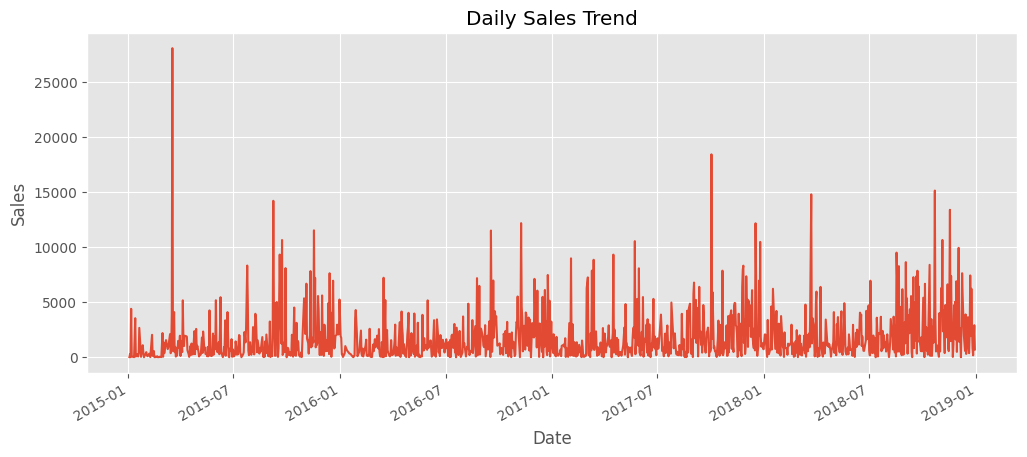

In [44]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

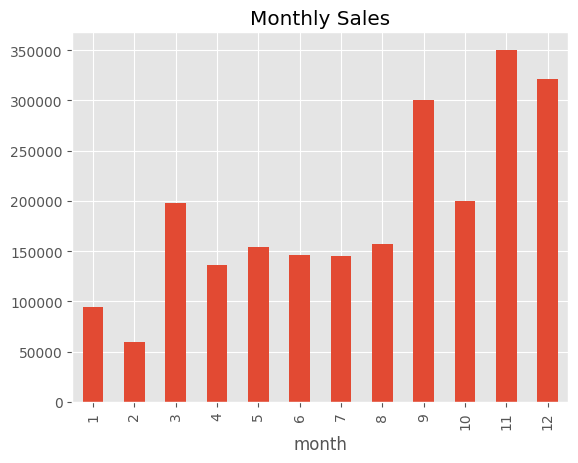

In [45]:
df['month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('month')['Sales'].sum()

monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.show()

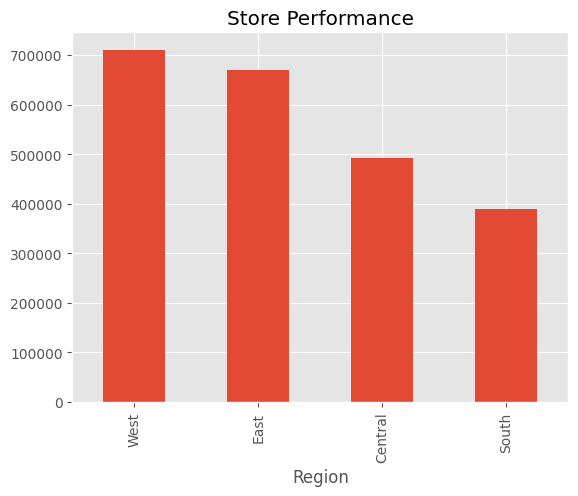

In [46]:
store_sales = df.groupby('Region')['Sales'].sum()

store_sales.sort_values(ascending=False).plot(kind='bar')
plt.title("Store Performance")
plt.show()

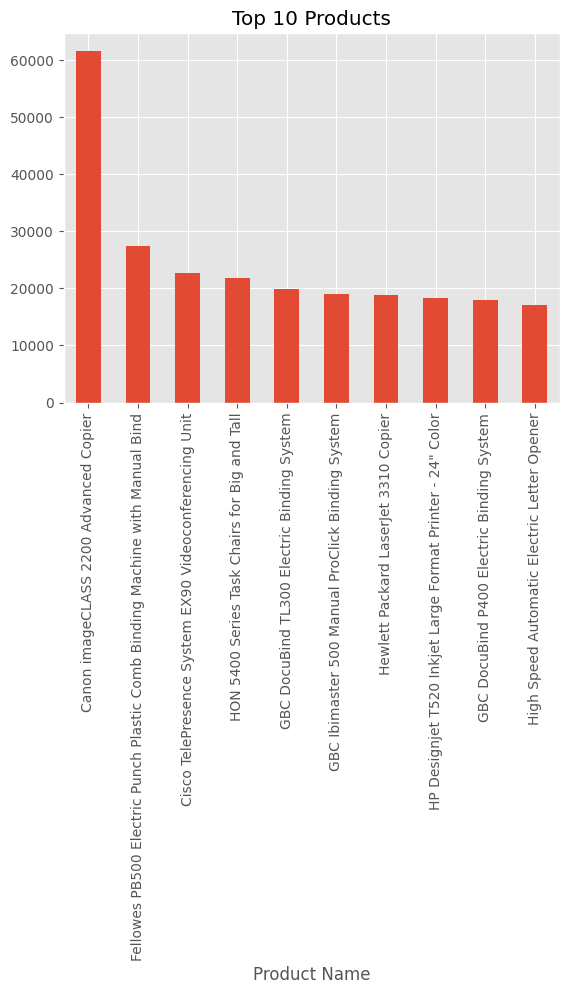

In [47]:
item_sales = df.groupby('Product Name')['Sales'].sum()

item_sales.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

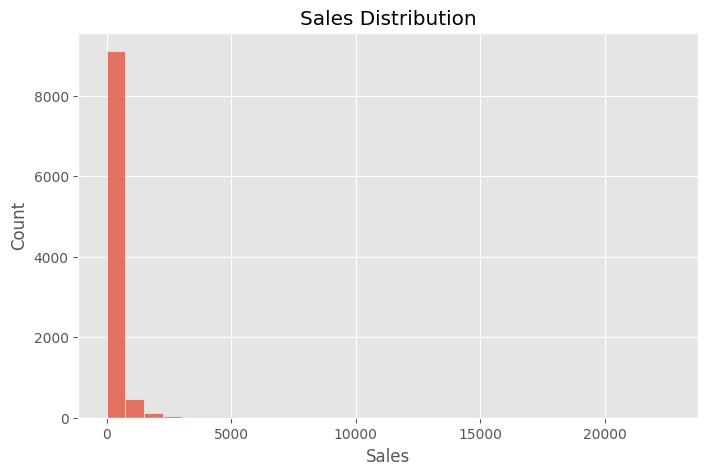

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

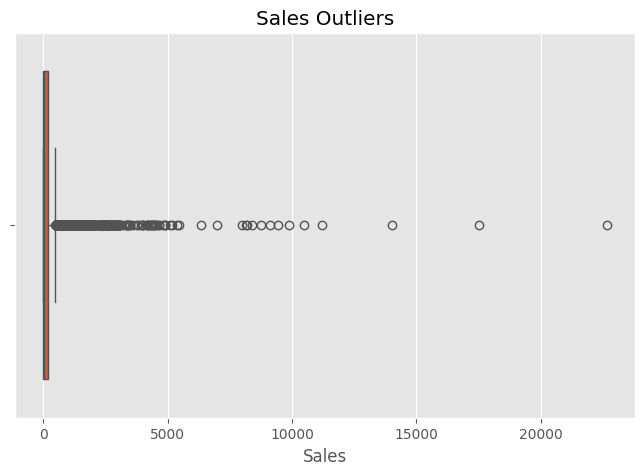

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

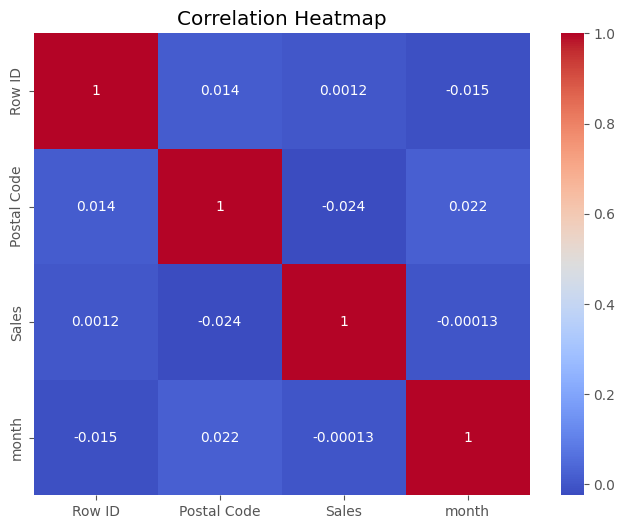

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()